In [14]:
import matplotlib.pyplot as plt

import torch

device = torch.device('cpu')#torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True


In [15]:
from orbitflows import HamiltonianMappingModel

model = HamiltonianMappingModel.load("best_mw_3")
model.flow.to(device)

Flow(
  (layers): ModuleList(
    (0-255): 256 x SymplecticCouplingLayer(
      (conditioner): SimpleNNConditioner(
        (layers): Sequential(
          (0): Linear(in_features=1, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=1, bias=True)
        )
      )
    )
  )
)

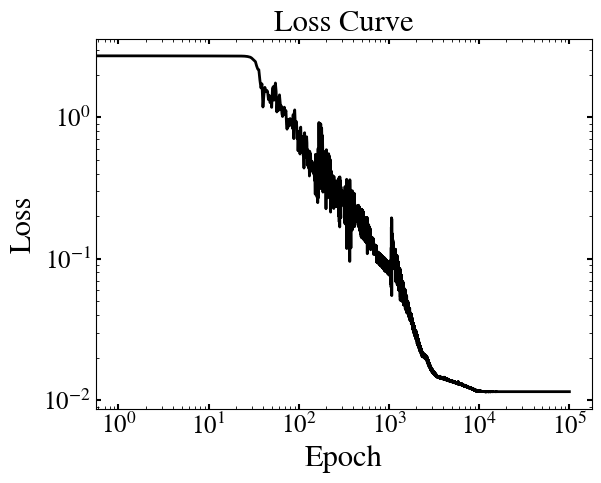

In [16]:
plt.loglog(model.loss_list, c='k', lw=2)
plt.xlabel('Epoch', fontsize=22)
plt.ylabel('Loss', fontsize=22)
plt.title('Loss Curve', fontsize=22)
plt.show()

In [17]:
import astropy.units as u
from orbitflows.util import generate_sho_orbits
ro = 8.0 * u.kpc
vo = 220.0 * u.km / u.s
n_orbits = 100
n_angles = 1000
omega0 = 1.5
z_max_0 = 0.01
z_max_1 = 0.9

ex_ps, ex_aa = generate_sho_orbits(n_orbits=n_orbits, omega=omega0, t_end = 2*torch.pi / omega0, n_steps=n_angles, r_bounds=torch.tensor([z_max_0, z_max_1]))
ex_model_ps = model.aa_to_ps(ex_aa.to(device=device, dtype=torch.float32))
z_max_list = torch.max(ex_model_ps[...,0], dim=1).values#ex_model_ps[:,0][:,0]*ro.value

In [18]:
training_bounds_ps, training_bounds_aa = generate_sho_orbits(n_orbits=2, omega=omega0, t_end = 2*torch.pi / omega0, n_steps=n_angles, r_bounds=[0.01, 0.75])
true_bounds_ps = model.aa_to_ps(training_bounds_aa.to(device=device, dtype=torch.float32))

z_max_bounds = torch.max(true_bounds_ps[...,0], dim=1).values #true_bounds_ps[:,0][:,0]*ro.value

In [19]:
z_max_bounds

tensor([0.0074, 1.0311], grad_fn=<MaxBackward0>)

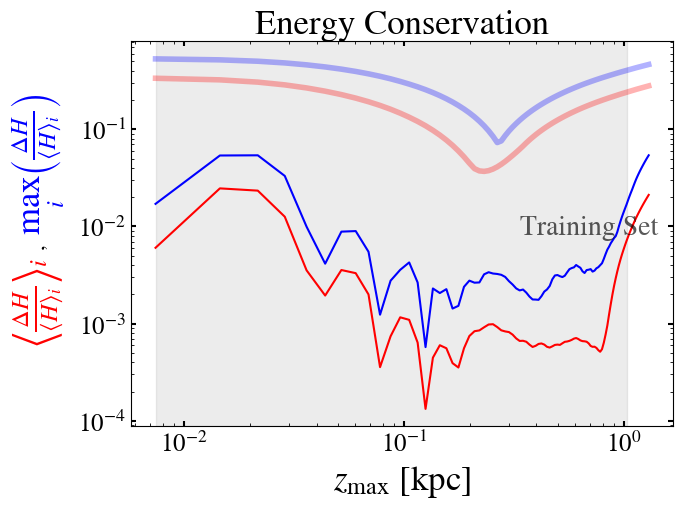

In [20]:
from orbitflows.util import max_error_along_orbs, mean_error_along_orbs
from orbitflows.dynamics import H
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))
y_max = torch.max(max_error_along_orbs(H(ex_ps, model.targetPotential)).detach().cpu())
y_min = torch.min(mean_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach().cpu())
y_mean = 10**torch.mean(torch.tensor([torch.log10(y_min), torch.log10(y_max)]))

plt.axvspan(z_max_bounds.detach().cpu()[0], z_max_bounds.detach().cpu()[1], alpha=0.15, color='gray')
plt.text(torch.mean(z_max_bounds).detach().cpu()*0.65, y_mean, "Training Set", fontsize=20, alpha=0.65)

ax.plot(z_max_list.detach().cpu(), max_error_along_orbs(H(ex_ps, model.targetPotential)).detach().cpu(), c='b', alpha=0.3, lw=4)
ax.plot(z_max_list.detach().cpu(), mean_error_along_orbs(H(ex_ps, model.targetPotential)).detach().cpu(),  c='r', alpha=0.3, lw=4)

ax.plot(z_max_list.detach().cpu(), max_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach().cpu(), label='Max along orbit', c='b')
ax.plot(z_max_list.detach().cpu(), mean_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach().cpu(), label='Mean along orbit', c='r')

ax.set_xlabel('$z_{\\text{max}}$ [kpc]', fontsize=25)
# plt.ylabel('$ \Delta H / \langle H \\rangle$', fontsize=25)
# Add colored vertical label pieces
ax.text(
    -0.17, 0.50, r"$\max_i \left ( \frac{\Delta H}{\langle H \rangle_{i}} \right )$",
    transform=ax.transAxes,
    color="blue",
    fontsize=25,
    rotation=90,
    ha="center",
    va="bottom"
)

ax.text(
    -0.17, 0.47, ",",
    transform=ax.transAxes,
    color="black",
    fontsize=16,
    rotation=90,
    ha="center",
    va="center"
)

ax.text(
    -0.17, 0.44, r"$\left \langle \frac{\Delta H}{\langle H \rangle_{i}} \right \rangle_{i}$",
    transform=ax.transAxes,
    color="red",
    fontsize=25,
    rotation=90,
    ha="center",
    va="top"
)

ax.set_title('Energy Conservation', fontsize=25)
ax.set_yscale('log')
ax.set_xscale('log')
plt.savefig('best_mw_H_conservation.png', dpi=200, bbox_inches='tight')
plt.show()

* **Red** = mean energy error along each orbit
* **Blue** = max energy error along each orbit

The thick lines are from before training.

In [21]:
arg_min_bound = torch.argmin(torch.abs(z_max_list - z_max_bounds[0])) 
arg_max_bound = torch.argmin(torch.abs(z_max_list - z_max_bounds[1])) 

print(f'Worst (log10) Error of All Points in the Training Set Domain: ')
print(f'{torch.log10(max_error_along_orbs(H(ex_model_ps, model.targetPotential))[arg_min_bound : arg_max_bound].max()).item():.2f}')

Worst (log10) Error of All Points in the Training Set Domain: 
-1.27


# Action Conservation

Tranform orbits integrated to action-angle coordinates and evaluate precision along orbits.

In [22]:
from galpy.actionAngle import actionAngleVerticalInverse 
from galpy.potential import MWPotential2014, toVerticalPotential
import numpy as np
from orbitflows.dynamics import H, MWPotential2014_1D
import torch
from tqdm import tqdm

def wrap_angles(aa):
    '''
    Wrap angles to [0, 2π) range
    '''
    below_zero_mask = aa[...,0] > np.pi
    aa[...,0][below_zero_mask] = aa[...,0][below_zero_mask] - 2*np.pi
    return aa

def generate_grid(n_orbits, nsteps, zmin, zmax):
    '''
    Generate a grid of orbits in the vertical MWPotential2014 at the solar radius,
    
    Parameters
    ----------
    n_orbits : int
        Number of orbits to generate (equally spaced in apocenter radius)
    nsteps : int
        Number of time steps to integrate each orbit for (equally spaced in angle)
    
    Returns
    -------
    xvs : np.ndarray
        Array of shape (n_orbits, nsteps, 2) containing the (z, vz) coordinates 
        of each orbit at each time step.
    aa : np.ndarray
        Array of shape (n_orbits, nsteps, 2) containing the (angle, action) coordinates 
        of each orbit at each time step.
    freqs : np.ndarray
        Array of shape (n_orbits,) containing the frequencies of each orbit.
    '''
    # define the potential
    mw = MWPotential2014
    mwvert = toVerticalPotential(mw, 1) # vertical MW potential at solar radius

    # create grid of radii and velocities
    zs = torch.linspace(zmin, zmax, n_orbits)
    vs = torch.zeros_like(zs)

    # compute the energies at the phase-space points
    Es = H(torch.vstack((zs, vs)).T, MWPotential2014_1D).numpy()

    # compute the actions and frequencies at these energies
    print("Setting up action-angle interpolation...")
    aA1Dinv= actionAngleVerticalInverse(pot=mwvert,nta=4*128,
                                            Es=Es,
                                            use_pointtransform=False)
    
    actions = []
    for E in tqdm(Es, desc="Computing actions for each energy"):
        actions.append(aA1Dinv.J(E))
    actions = np.array(actions)
    action_list = np.repeat(actions, nsteps).reshape(n_orbits, nsteps)     

    # define equally spaced angles
    angles = np.linspace(0, 2 * np.pi, nsteps)
    angle_list = np.repeat(angles, n_orbits).reshape(nsteps, n_orbits).T

    # combine actions and angles in single array
    aa = np.array([angle_list, action_list]).T.swapaxes(0,1)

    # compute (z, vz) coordinates for each (action, angle) pair
    xvs = []
    freqs = []
    for action in tqdm(actions, desc="Computing (z, vz) and frequencies for each (action, angle) pair"):
        freqs.append(aA1Dinv.Freqs(action))
        xvs.append(np.array(aA1Dinv(action, angles)))
    xvs = np.array(xvs).swapaxes(1,2)

    return torch.tensor(xvs), torch.tensor(wrap_angles(aa)), torch.tensor(freqs)

In [23]:
analytic_ps, analytic_aa, freqs_analytic = generate_grid(n_orbits=100, nsteps=1000, zmin=min(z_max_list), zmax=max(z_max_list))

Setting up action-angle interpolation...


Computing actions for each energy: 100%|██████████| 100/100 [00:00<00:00, 38850.54it/s]
Computing (z, vz) and frequencies for each (action, angle) pair: 100%|██████████| 100/100 [00:04<00:00, 23.22it/s]


In [24]:
#print(f'Energy conservation of training set along each orbit:\n {torch.std(H(ps_J_angle_grid, model.targetPotential), dim=1)}')

In [25]:
predicted_aa = model.ps_to_aa(analytic_ps.to(dtype=torch.float32))
predicted_J = predicted_aa[..., 1]
analytic_J = analytic_aa[::50, ..., 1]

In [26]:
z_max_list_2 = torch.max(analytic_ps[...,0], dim=1).values

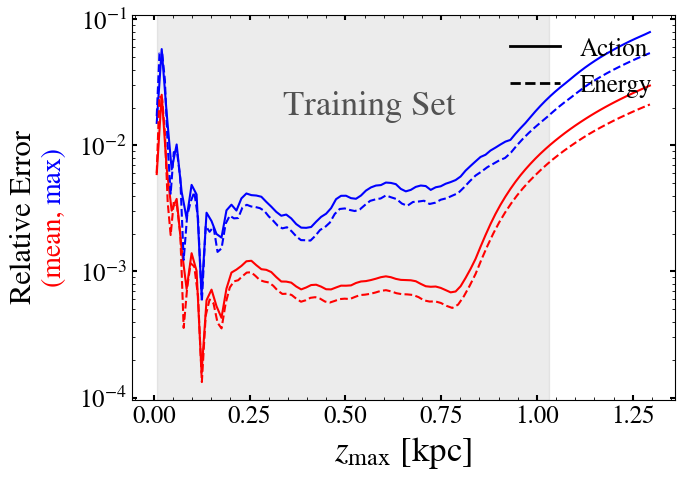

In [27]:
from orbitflows.util import max_error_along_orbs, mean_error_along_orbs
from orbitflows.dynamics import H
import numpy as np
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 5))
y_max = torch.max(max_error_along_orbs(predicted_J.detach().cpu()))
y_min = torch.min(mean_error_along_orbs(predicted_J.detach().cpu()))
y_mean = 10**torch.mean(torch.tensor([torch.log10(y_min), torch.log10(y_max)]))

plt.axvspan(z_max_bounds.detach().cpu()[0], z_max_bounds.detach().cpu()[1], alpha=0.15, color='gray')
plt.text(torch.mean(z_max_bounds).detach().cpu()*0.65, y_mean*5, "Training Set", fontsize=25, alpha=0.65)

ax.plot(z_max_list_2.detach().cpu(), max_error_along_orbs(predicted_J.detach().cpu()), label='Max along orbit', c='b')
ax.plot(z_max_list_2.detach().cpu(), mean_error_along_orbs(predicted_J.detach().cpu()), label='Mean along orbit', c='r')

ax.plot(z_max_list.detach().cpu(), max_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach().cpu(), label='Max along orbit', c='b', ls='--')
ax.plot(z_max_list.detach().cpu(), mean_error_along_orbs(H(ex_model_ps, model.targetPotential)).detach().cpu(), label='Mean along orbit', c='r', ls='--')

legend_lines = [
    Line2D([0], [0], color='black', lw=2, linestyle='-'),
    Line2D([0], [0], color='black', lw=2, linestyle='--'),
]
ax.legend(handles=legend_lines, labels=['Action', 'Energy'], loc='upper right', frameon=False, fontsize=18)

ax.set_xlabel('$z_{\\text{max}}$ [kpc]', fontsize=25)
# plt.ylabel('$ \Delta H / \langle H \\rangle$', fontsize=25)
# Add colored vertical label pieces
ax.text(-0.17, 0.25, "Relative Error\n",
    transform=ax.transAxes,
    color="k",
    fontsize=22,
    rotation=90,
    ha="center",
    va="bottom")
ax.text(
    -0.17, 0.51, "\nmax)",
    transform=ax.transAxes,
    color="blue",
    fontsize=20,
    rotation=90,
    ha="center",
    va="bottom"
)

ax.text(
    -0.17, 0.51, " ",
    transform=ax.transAxes,
    color="black",
    fontsize=16,
    rotation=90,
    ha="center",
    va="center"
)

ax.text(
    -0.17, 0.51, "\n(mean, ",
    transform=ax.transAxes,
    color="red",
    fontsize=20,
    rotation=90,
    ha="center",
    va="top"
)

# ax.set_title('Action and Energy Error\nAlong Orbits', fontsize=20)
ax.set_yscale('log')
plt.savefig('best_mw_conservation_laws.png', dpi=200, bbox_inches='tight')
plt.show()

In [28]:
model.flow

Flow(
  (layers): ModuleList(
    (0-255): 256 x SymplecticCouplingLayer(
      (conditioner): SimpleNNConditioner(
        (layers): Sequential(
          (0): Linear(in_features=1, out_features=64, bias=True)
          (1): ReLU()
          (2): Linear(in_features=64, out_features=1, bias=True)
        )
      )
    )
  )
)

**Max Error**: $\max_i \left ( \frac{\Delta H}{\langle H \rangle_{i}} \right )$

**Mean error**: $\left \langle \frac{\Delta H}{\langle H \rangle_{i}} \right \rangle_{i}$

# Frequency Prediction